<a href="https://colab.research.google.com/github/serena-h12/cap-comp215/blob/main/project301.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Biometric Identification System Simulation
This model takes a fingerprint as input and processes it using the algorithm SIFT. It then compares the fingerprint to a number of fingerprints in a database and finds the best match. A person can then be identified and some of their personal data can be retrieved. In other words, this model simulates the process of how biometric systems in the real world use fingerprint data in order to identify individuals.

In [1]:
import zipfile
import os
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
import gdown

In [2]:
#Download zip file from Google Drive
file_id = '15-4urolciLZJf4SdypWyigl8jLOGtSNS'
output = 'fingerprints.zip'

gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=15-4urolciLZJf4SdypWyigl8jLOGtSNS
From (redirected): https://drive.google.com/uc?id=15-4urolciLZJf4SdypWyigl8jLOGtSNS&confirm=t&uuid=83516a14-8bdb-41a6-bb8a-9d370ff9af85
To: /content/fingerprints.zip
100%|██████████| 870M/870M [00:11<00:00, 74.6MB/s]


'fingerprints.zip'

In [3]:
#Written with assistance from ChatGPT
def get_finger_print(zip_file, target_folder='Db1_a'):
    """
    Extracts the zip file and returns the path of the fingerprint images.
    """
    extract_dir = 'fingerprint_data'

    if os.path.exists(extract_dir):
        shutil.rmtree(extract_dir)

    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    finger_prints = []
    for root, _, files in os.walk(extract_dir):
        if target_folder in root:
            for file in files:
                if file.lower().endswith('.tif'):
                    finger_prints.append(os.path.join(root, file))

    return finger_prints

In [4]:
#Asked ChatGPT to create personal records for ten made up people
dataset = [
    {
        "user_id": "U001",
        "full_name": "Liam Chen",
        "age": 28,
        "email": "liam.chen@example.com",
        "phone": "+1-604-555-1023",
        "address": "123 Main St, Vancouver, BC",
        "occupation": "Software Developer",
    },
    {
        "user_id": "U002",
        "full_name": "Sofia Martinez",
        "age": 34,
        "email": "sofia.martinez@example.com",
        "phone": "+1-778-555-3345",
        "address": "456 Oak Ave, Burnaby, BC",
        "occupation": "Nurse",
    },
    {
        "user_id": "U003",
        "full_name": "Ethan Patel",
        "age": 41,
        "email": "ethan.patel@example.com",
        "phone": "+1-604-555-8890",
        "address": "789 Pine Rd, Surrey, BC",
        "occupation": "Business Owner",
    },
    {
        "user_id": "U004",
        "full_name": "Olivia Thompson",
        "age": 25,
        "email": "olivia.thompson@example.com",
        "phone": "+1-236-555-7781",
        "address": "321 Maple Dr, Richmond, BC",
        "occupation": "Student",
    },
    {
        "user_id": "U005",
        "full_name": "Noah Dubois",
        "age": 37,
        "email": "noah.dubois@example.com",
        "phone": "+1-604-555-6612",
        "address": "654 Cedar St, North Vancouver, BC",
        "occupation": "Architect",
    },
    {
        "user_id": "U006",
        "full_name": "Ava Singh",
        "age": 30,
        "email": "ava.singh@example.com",
        "phone": "+1-778-555-4499",
        "address": "987 Birch Ln, Coquitlam, BC",
        "occupation": "Data Analyst",
    },
    {
        "user_id": "U007",
        "full_name": "Lucas Brown",
        "age": 45,
        "email": "lucas.brown@example.com",
        "phone": "+1-604-555-2201",
        "address": "159 Spruce St, Delta, BC",
        "occupation": "Police Officer",
    },
    {
        "user_id": "U008",
        "full_name": "Mia Nguyen",
        "age": 22,
        "email": "mia.nguyen@example.com",
        "phone": "+1-236-555-6677",
        "address": "753 Willow Ave, Langley, BC",
        "occupation": "Retail Worker",
    },
    {
        "user_id": "U009",
        "full_name": "Daniel Kim",
        "age": 39,
        "email": "daniel.kim@example.com",
        "phone": "+1-778-555-8844",
        "address": "852 Elm St, Vancouver, BC",
        "occupation": "Cybersecurity Specialist",
    },
    {
        "user_id": "U010",
        "full_name": "Emily Johnson",
        "age": 31,
        "email": "emily.johnson@example.com",
        "phone": "+1-604-555-9933",
        "address": "246 Aspen Rd, West Vancouver, BC",
        "occupation": "Marketing Manager",
    }
]

#Give each user in the dataset a biometric identity by linking each of them to a unique fingerprint path
zip_file = 'fingerprints.zip'
finger_prints = get_finger_print(zip_file, 'Db1_a')

for index, record in enumerate(dataset):
    if index < len(finger_prints):
        record["fingerprint_path"] = finger_prints[index]

print(dataset)

[{'user_id': 'U001', 'full_name': 'Liam Chen', 'age': 28, 'email': 'liam.chen@example.com', 'phone': '+1-604-555-1023', 'address': '123 Main St, Vancouver, BC', 'occupation': 'Software Developer', 'fingerprint_path': 'fingerprint_data/74034_3_En_4_MOESM1_ESM/FVC2002/Dbs/Db1_a/32_4.tif'}, {'user_id': 'U002', 'full_name': 'Sofia Martinez', 'age': 34, 'email': 'sofia.martinez@example.com', 'phone': '+1-778-555-3345', 'address': '456 Oak Ave, Burnaby, BC', 'occupation': 'Nurse', 'fingerprint_path': 'fingerprint_data/74034_3_En_4_MOESM1_ESM/FVC2002/Dbs/Db1_a/77_6.tif'}, {'user_id': 'U003', 'full_name': 'Ethan Patel', 'age': 41, 'email': 'ethan.patel@example.com', 'phone': '+1-604-555-8890', 'address': '789 Pine Rd, Surrey, BC', 'occupation': 'Business Owner', 'fingerprint_path': 'fingerprint_data/74034_3_En_4_MOESM1_ESM/FVC2002/Dbs/Db1_a/12_2.tif'}, {'user_id': 'U004', 'full_name': 'Olivia Thompson', 'age': 25, 'email': 'olivia.thompson@example.com', 'phone': '+1-236-555-7781', 'address': '

In [5]:
#Written with assistance from ChatGPT
def load_fingerprint(path):
    """
    Loads and reads a fingerprint image from inputed path and verifies it is in a suitable format by
    converting it to greyscale and normalizing the pixel values (8-bit). The processed image is then
    returned.
    """
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Could not read image: {path}")

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if img.dtype != np.uint8:
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
        img = img.astype(np.uint8)

    return img

In [6]:
#Written with assistance from ChatGPT
def compare_fingerprints(path1, path2):
    """
    Takes in two fingerprint images and ensures they are in the correct format. Then uses SIFT to find
    unique points in the fingerprints and uses a brute force matcher to compare them. Good matches are
    filtered using Lowe's ratio test and the number of good matches is returned.
    """
    image1 = load_fingerprint(path1)
    image2 = load_fingerprint(path2)

    sift = cv2.SIFT_create()

    kp1, des1 = sift.detectAndCompute(image1, None)
    kp2, des2 = sift.detectAndCompute(image2, None)

    if des1 is None or des2 is None:
        return 0

    bf = cv2.BFMatcher()

    matches = bf.knnMatch(des1, des2, k=2)

    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    return len(good_matches)

In [7]:
def find_matching_user(input_fingerprint_path, database, threshold=70):
    """
    Takes a fingerprint as input and compares it to all fingerprints in the database,then finds and returns the best match based on a threshold
    value.
    """
    user_found = None
    highest_score = -1

    for user in database:
        stored_path = user.get("fingerprint_path")

        score = compare_fingerprints(input_fingerprint_path, stored_path)

        if score > highest_score:
            highest_score = score
            user_found = user

    if highest_score >= threshold:
        return user_found, highest_score

    return None, highest_score

In [8]:
def show_match(input_path, matched_path):
    """
    Asked ChatGPT to write a visual demo function that displays the input fingerprint and the matched fingerprint side by side.
    """
    img1 = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(matched_path, cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img1, cmap='gray')
    plt.title("Input Fingerprint")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img2, cmap='gray')
    plt.title("Matched Fingerprint")
    plt.axis('off')

    plt.show()

In [9]:
def find_match(path, dataset):
  """
  Takes a fingerprint as input and compares it to all fingerprints in the database,then determines whether there is a valid match. If valid match
  is found, then an image is displayed showing the input fingerprint and the matched fingerprint, and the matched user's full name and email
  is printed.
  """
  match, score = find_matching_user(path, dataset)

  if match:
      show_match(path, match["fingerprint_path"])
      print(f"Match found with user: {match['full_name']}")
      print(f"Email: {match['email']}")
  else:
      print("No match found")

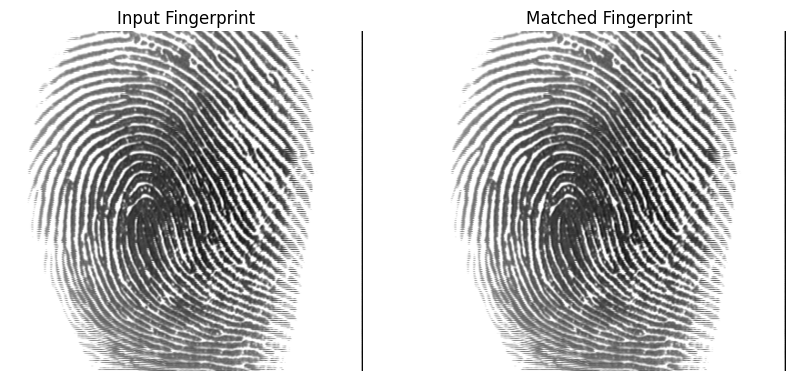

Match found with user: Olivia Thompson
Email: olivia.thompson@example.com


In [10]:
#Tests
test_fp = dataset[3]["fingerprint_path"]
find_match(test_fp, dataset)



